# EDA HPP — Version minimale et claire

**Objectifs**
- Vérifier la structure des données, la complétude et les incohérences évidentes.
- Définir le périmètre des variables **connues avant l’accouchement** pour éviter toute fuite de cible.
- Produire un dataset propre “interim” pour la suite (features, split temporel).

**Règles**
- 1 tableau par sous-section, pas de mur de graphiques.
- Pas d'inférence clinique ici. Juste l’hygiène des données.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path("../00_Data/Bourgogne20132023.csv")           # adapte si besoin
DICO = Path("../00_Data/dico_var.csv")                   # dictionnaire: variable, label, type, timing(?)
assert RAW.exists() and DICO.exists()

df = pd.read_csv(RAW, low_memory=False)
dico = pd.read_csv(DICO, index_col=0)

# Colonnes propres
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
dico.index = [i.strip().lower().replace(" ", "_") for i in dico.index]

# Optionnel: merge dico si tu as des infos 'moment_dispo' (avant/après accouchement)
dico = dico.reindex(df.columns)
display(df.head(3))
display(dico.head(10))
print(df.shape)


,id_chain,id_acc,terme,poids_mere,taille_mere,parite,dosecortico,sdecl,codepost,type_grossesse,...,bas_risque,hta_tot,vitalite,mod_acc,mp,morti_peri,codepsl,cgr,nb_cgr,hpp_trans
0,1,1,39.9,NaN,NaN,NaN,NaN,NaN,21220,NaN,...,Risque,0,vivant,vb,0,0,NaN,NaN,NaN,0
1,1,1,41.6,74.0,178.0,0.0,NaN,0,21201,NaN,...,Risque,0,vivant,vb,0,0,NaN,NaN,NaN,0
2,1,1,41.2,62.0,167.0,2.0,NaN,NaN,21000,NaN,...,Risque,0,vivant,vb,0,0,NaN,NaN,NaN,0


,Intitulé/modalités
id_chain,Identifiant
id_acc,Identifiant accouchement: \nNombre de fois le ...
terme,Terme à l'accouchement en semaine d aménorrhée...
poids_mere,Poids de la mére (en kg)
taille_mere,Taille de la mére (en cm)
parite,Parité obstétricale : nombre d'enfants issues ...
dosecortico,"Corticotherapie : dose cumulée : 0,12,24,36…...mg"
sdecl,Declenchement : Non/Oui
codepost,NaN
type_grossesse,Type de grossesse


(65535, 145)


In [3]:
def missing_summary(data: pd.DataFrame, top=30):
    m = data.isna().mean().sort_values(ascending=False)
    out = pd.DataFrame({"missing_rate": m, "dtype": data.dtypes.astype(str)})
    return out.head(top)

def target_prevalence(data: pd.DataFrame, target="hpp_trans"):
    if target not in data:
        return "target non trouvée"
    p = data[target].mean()
    return {"n": len(data), "positifs": data[target].sum(), "prevalence": round(100*p, 3)}

def numeric_overview(data: pd.DataFrame, top=15):
    num = data.select_dtypes(include=[np.number])
    desc = num.describe().T
    # ajouter quelques flags utilitaires
    desc["n_missing"] = num.isna().sum()
    desc["pct_missing"] = (num.isna().mean()*100).round(2)
    return desc.sort_values("pct_missing", ascending=False).head(top)

def categorical_overview(data: pd.DataFrame, top=15):
    cat = data.select_dtypes(exclude=[np.number])
    rows = []
    for c in cat.columns:
        vc = cat[c].value_counts(dropna=False)
        rows.append({"col": c, "n_unique": cat[c].nunique(dropna=True), "top": vc.index[0], "top_freq": int(vc.iloc[0])})
    out = pd.DataFrame(rows).sort_values("n_unique", ascending=False)
    return out.head(top)

print("Aperçu target:", target_prevalence(df, "hpp_trans"))
display(missing_summary(df, top=30))
display(numeric_overview(df, top=15))
display(categorical_overview(df, top=15))


Aperçu target: {'n': 65535, 'positifs': 471, 'prevalence': 0.719}


,missing_rate,dtype
acc_hh,0.000000,int64
act_pres,0.004608,float64
age_m,0.000015,float64
aide_procreation,0.670634,float64
allait,0.000000,int64
allaitement_mat,0.698405,float64
amp,0.982376,object
anest_gene,0.000000,int64
anest_peri,0.000000,int64
annee,0.000000,int64


,count,mean,std,min,25%,50%,75%,max,n_missing,pct_missing
parite_cor,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65535,100.00
crib,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65535,100.00
autre_debut_trav,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65535,100.00
nb_cgr,694.0,3.102305,2.225957,1.0,2.00,2.00,3.00,17.0,64841,98.94
codepsl,694.0,4172.863112,29.337465,4171.0,4171.00,4171.00,4171.00,4863.0,64841,98.94
dosecortico,3639.0,22.626271,5.950818,0.0,24.00,24.00,24.00,84.0,61896,94.45
cesa_avt,6418.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.0,59117,90.21
ph_veineux,9485.0,7.711678,18.923802,0.0,7.27,7.32,7.36,736.0,56050,85.53
pc,9622.0,34.647215,36.133447,20.0,33.00,34.00,35.00,3490.0,55913,85.32
apgar10,9634.0,9.715591,1.471015,0.0,10.00,10.00,10.00,99.0,55901,85.30


,col,n_unique,top,top_freq
7,diagnostique_reg,11772,NaN,49687
8,dat_acc,3992,2014-01-23,60
9,d_naiss,3992,2014-01-23,60
1,codepost,698,21000,15484
13,autre_indication_decl,561,NaN,64693
12,indication_decl,209,NaN,62969
14,precision_decl,28,NaN,64195
15,autre_precision_decl,10,NaN,65525
11,declenchement,9,NaN,55219
2,type_grossesse,7,NaN,43946


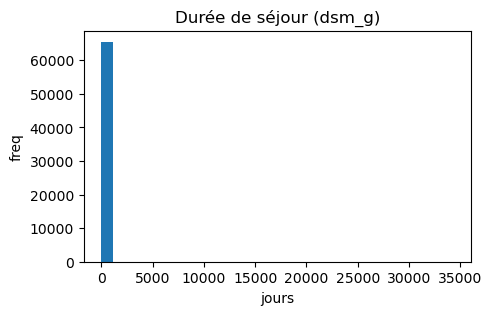

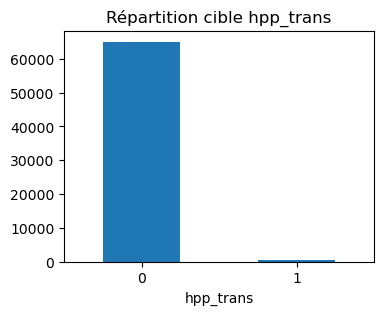

In [4]:
import matplotlib.pyplot as plt

if "dsm_g" in df.columns:
    s = df["dsm_g"].dropna()
    plt.figure(figsize=(5,3))
    s.plot(kind="hist", bins=30)
    plt.title("Durée de séjour (dsm_g)"); plt.xlabel("jours"); plt.ylabel("freq")
    plt.show()

if "hpp_trans" in df.columns:
    vc = df["hpp_trans"].value_counts().sort_index()
    plt.figure(figsize=(4,3))
    vc.plot(kind="bar")
    plt.title("Répartition cible hpp_trans"); plt.xticks(rotation=0)
    plt.show()


In [5]:
report = {}

# Duplicats (sur un id si existant, sinon sur tout)
id_cols = [c for c in ["id_patiente", "id_dossier"] if c in df.columns]
if id_cols:
    dup = df.duplicated(subset=id_cols).sum()
    report["duplicates_on_id"] = int(dup)
else:
    report["duplicates_full_row"] = int(df.duplicated().sum())

# Dates de référence
date_cols = [c for c in df.columns if "date" in c or "datetime" in c]
for c in date_cols:
    try:
        d = pd.to_datetime(df[c], errors="coerce")
        if d.notna().any():
            report[f"{c}_min"] = str(d.min())
            report[f"{c}_max"] = str(d.max())
    except Exception:
        pass

# Valeurs impossibles simples
if "age_m" in df.columns:
    report["age_m_negative_or_gt60"] = int(((df["age_m"]<0) | (df["age_m"]>60)).sum())

if "dsm_g" in df.columns:
    report["dsm_g_negative_or_gt270"] = int(((df["dsm_g"]<0) | (df["dsm_g"]>270)).sum())

report


{'duplicates_full_row': 0,
 'age_m_negative_or_gt60': 1,
 'dsm_g_negative_or_gt270': 17}

In [6]:
# Exemple: tag depuis le dico si tu as une colonne 'moment_dispo' = {'avant','pendant','apres'}
if "moment_dispo" in dico.columns:
    avant_cols = dico.index[dico["moment_dispo"].str.lower().eq("avant")].tolist()
else:
    # Fallback ultra simple: liste manuelle maintenue ici (à compléter proprement)
    # Garde les tiennes : cat_nom_features, cat_ord_features, binaires, etc. uniquement "avant"
    avant_cols = [c for c in df.columns if c in [
        # ex:
        "age_m","poids_mere","ta_m","hta_gest","hta_chro","hta_tot","amp","parite",
        "tabac","diabete","hb","platelets","...etc..."
    ]]

target = "hpp_trans"
cols_keep = sorted(list(set(avant_cols + ([target] if target in df.columns else []))))
df_avant = df[cols_keep].copy()

# Nettoyages minimaux documentés
if "hta_tot" in df_avant.columns and {"hta_gest","hta_chro"}.issubset(df_avant.columns):
    df_avant = df_avant.drop(columns=["hta_gest","hta_chro"])

if "poids_mere" in df_avant.columns and df_avant["poids_mere"].isna().mean() > 0.8:
    df_avant = df_avant.drop(columns=["poids_mere"])

# Age manquant ultra rare → drop ligne
if "age_m" in df_avant.columns:
    df_avant = df_avant.dropna(subset=["age_m"])

# dsm_g est “après” → ne pas garder ici; si présent par erreur, on l’enlève
if "dsm_g" in df_avant.columns:
    df_avant = df_avant.drop(columns=["dsm_g"])

print(df_avant.shape)
print("Prévalence cible (subset):", target_prevalence(df_avant, target))


(65534, 8)
Prévalence cible (subset): {'n': 65534, 'positifs': 471, 'prevalence': 0.719}


In [7]:
# Winsorisation très light si nécessaire sur 2 variables clés, sinon laisse au pipeline
# Exemple simple sur hb/platelets
for col, lo, hi in [("hb", 5, 18), ("platelets", 40, 900)]:
    if col in df_avant.columns:
        df_avant.loc[df_avant[col]<lo, col] = lo
        df_avant.loc[df_avant[col]>hi, col] = hi

# Export "interim"
OUT = Path("data/interim/hpp_clean.parquet")
OUT.parent.mkdir(parents=True, exist_ok=True)
df_avant.to_parquet(OUT, index=False)

# Petit résumé final
summary = {
    "rows": len(df_avant),
    "cols": df_avant.shape[1],
    "missing_rate_mean_%": round(df_avant.isna().mean().mean()*100, 2),
    "target_prevalence_%": round(df_avant[target].mean()*100, 3) if target in df_avant else None
}
summary


{'rows': 65534,
 'cols': 8,
 'missing_rate_mean_%': 16.75,
 'target_prevalence_%': 0.719}